# Vehicle Maintenance - ML Model Training
This notebook contains the complete pipeline to train and evaluate a Random Forest Classifier on component-level maintenance rules.

### **Cell 1: Imports and Configuration**

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
import sys
print(sys.executable)

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Configuration
INPUT_FILE = 'vehicle_data.csv'
MODEL_FILE = 'vehicle_model.pkl'
CLASS_NAMES = ['Healthy', 'Warning', 'Critical']

Matplotlib is building the font cache; this may take a moment.


/opt/homebrew/opt/python@3.13/bin/python3.13


### **Cell 2: Load and Prepare Data**

In [3]:
# Load dataset
if not os.path.exists(INPUT_FILE):
    print(f"Error: {INPUT_FILE} NOT found. Please upload it to your workspace.")
else:
    df = pd.read_csv(INPUT_FILE)
    
    # Preprocessing
    X = df.drop('health_status', axis=1)
    y = df['health_status']
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"Data loaded! Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

Data loaded! Training samples: 4000 | Testing samples: 1000


### **Cell 3: Train the Model with Pipeline**

In [4]:
print("Training Random Forest Classifier Pipeline...")

# Define preprocessing for categorical columns
categorical_features = ['component']
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Keep numeric features as they are
numeric_features = ['current_km', 'current_months', 'condition_metric_value']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', 'passthrough', numeric_features)
    ])
    
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

model.fit(X_train, y_train)

# Generate Predictions for the next cells
y_pred = model.predict(X_test)
print("Model training complete!")

Training Random Forest Classifier Pipeline...
Model training complete!


### **Cell 4: Overall Accuracy & Classification Report**

In [5]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Test accuracy: 98.30%

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.99      0.99       262
     Warning       1.00      0.61      0.76        36
    Critical       0.98      1.00      0.99       702

    accuracy                           0.98      1000
   macro avg       0.99      0.87      0.91      1000
weighted avg       0.98      0.98      0.98      1000



### **Cell 5: Confusion Matrix Visualization**

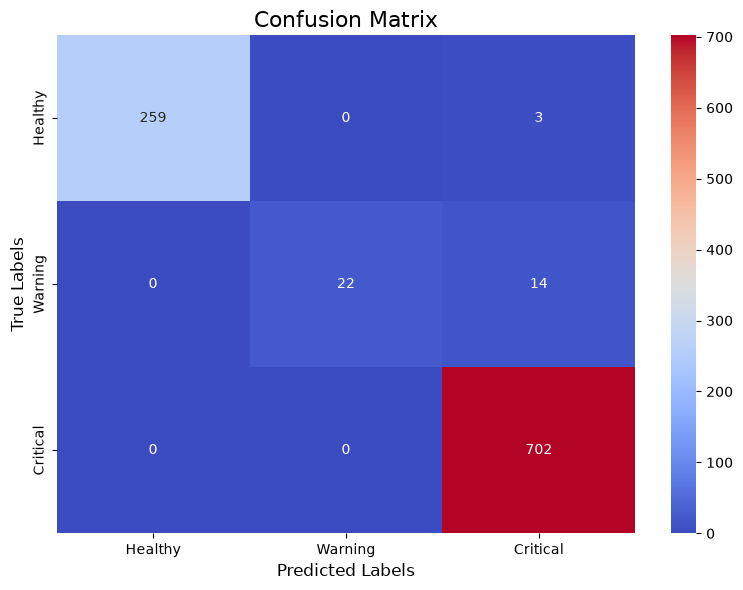

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', 
            xticklabels=CLASS_NAMES, 
            yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()
plt.show()

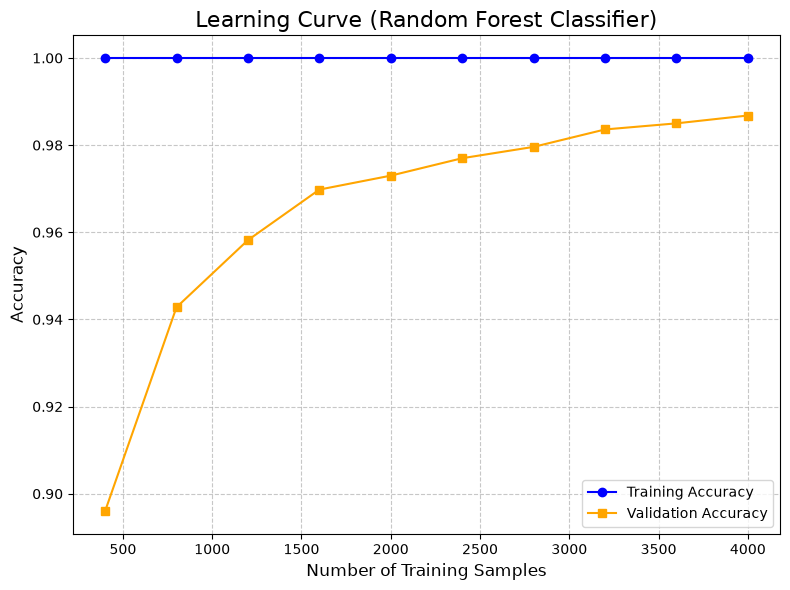

In [7]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Calculate learning curve data
train_sizes, train_scores, val_scores = learning_curve(
    model, X, y, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

# Calculate means and standard deviations
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Plot the Learning Curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training Accuracy', color='blue', marker='o')
plt.plot(train_sizes, val_mean, label='Validation Accuracy', color='orange', marker='s')

plt.title('Learning Curve (Random Forest Classifier)', fontsize=16)
plt.xlabel('Number of Training Samples', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


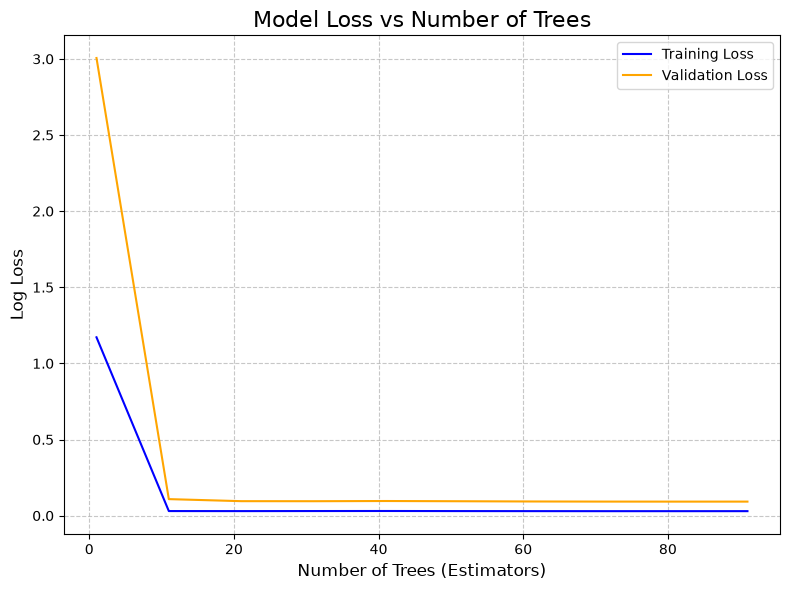

In [8]:
from sklearn.model_selection import validation_curve
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
import numpy as np

# We want to test the model with different numbers of trees (similar to epochs)
param_range = np.arange(1, 101, 10) # Testing from 1 to 100 trees

# Calculate the Validation Curve using "neg_log_loss" to simulate deep learning loss
train_scores, val_scores = validation_curve(
    model, X, y, param_name="classifier__n_estimators", 
    param_range=param_range, cv=3, scoring="neg_log_loss", n_jobs=-1
)

# Convert negative log loss to positive loss for the plot
train_loss = -np.mean(train_scores, axis=1)
val_loss = -np.mean(val_scores, axis=1)

# Plot the Model Loss
plt.figure(figsize=(8, 6))
plt.plot(param_range, train_loss, label='Training Loss', color='blue')
plt.plot(param_range, val_loss, label='Validation Loss', color='orange')

plt.title('Model Loss vs Number of Trees', fontsize=16)
plt.xlabel('Number of Trees (Estimators)', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### **Cell 6: Save Model**

In [6]:
joblib.dump(model, MODEL_FILE)
print(f"Model saved successfully as '{MODEL_FILE}'.")

Model saved successfully as 'vehicle_model.pkl'.
